## Importación

In [1]:
from pathlib import Path
import sys
import yaml

import pandas as pd
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR/'src'))

from utils.plot_continuo import *
from utils.plot_categorico import *
from utils.test_medidas import *

## Gestión de rutas absolutas

In [2]:
DATA_FILE = BASE_DIR / 'data' / 'raw' / 'loan_dataset_20000.csv'
CONFIG_FILE = BASE_DIR / 'config' / '01_feature_engineering.yaml'
FE_DATA_DIR = BASE_DIR / 'data' / 'Feature_Engineering'

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_FILE: {DATA_FILE}")
print(f"CONFIG_FILE: {CONFIG_FILE}")

BASE_DIR: /home/jair/Proyectos/Loan_Status_Prediction
DATA_FILE: /home/jair/Proyectos/Loan_Status_Prediction/data/raw/loan_dataset_20000.csv
CONFIG_FILE: /home/jair/Proyectos/Loan_Status_Prediction/config/01_feature_engineering.yaml


## Obtención de los datos

In [3]:
df = pd.read_csv(DATA_FILE)
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


## Configuraciónde hiperparpametros

In [4]:
with open(CONFIG_FILE, 'r') as f:
    config = yaml.safe_load(f)

seed = config['seed']
random.seed(seed)
np.random.seed(seed)

test_size = config['data_split']['test_size']
random_state = config['seed']

## Validación

In [5]:
variable_objetivo = config['target_variable']
X = df.drop(variable_objetivo, axis=1)
y = df[variable_objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = config['data_split']['test_size'],
    random_state = random_state,
    stratify = y)

In [6]:
train = pd.concat([X_train, y_train], axis = 1)
test = pd.concat([X_test, y_test], axis = 1)

train.to_csv(FE_DATA_DIR / config['data_split']['train_set_pre'])
test.to_csv(FE_DATA_DIR / config['data_split']['test_set_pre'])

print('Dimensiones train:')
print(f'Filas: {train.shape}')
print('Dimensiones test:')
print(f'Filas: {test.shape}')

Dimensiones train:
Filas: (16000, 22)
Dimensiones test:
Filas: (4000, 22)


## Transformaciónes

In [7]:
numeric_cols = ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'num_of_delinquencies']
categoric_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_term', 'public_records']

### Variables Numéricas

In [8]:
# Discretizar variable age

bins = [20, 29, 35, 40, 50, 75]
labels = ['joven', 'adulto_joven', 'adulto', 'adulto_mayor', '3_Edad']
train['age_group'] = pd.cut(df['age'], bins = bins, labels = labels)
train

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back,age_group
3928,28,Male,Single,Master's,46710.75,3892.56,Employed,0.312,773,29588.02,...,951.81,B2,3,38633.75,34223.23,1,0,1,1,joven
12469,34,Female,Married,High School,40889.05,3407.42,Employed,0.301,775,500.00,...,16.06,B5,3,51105.18,45972.71,2,0,2,1,adulto_joven
1362,60,Female,Single,High School,13552.37,1129.36,Employed,0.192,748,21230.36,...,687.94,B1,5,21432.29,8984.88,1,0,1,1,3_Edad
2979,57,Male,Widowed,High School,23886.41,1990.53,Employed,0.265,648,6602.02,...,228.70,D5,5,37217.80,20047.32,2,0,2,1,3_Edad
13191,23,Male,Married,High School,57877.02,4823.08,Employed,0.083,594,17108.03,...,588.71,E4,3,88035.39,56457.58,1,0,1,1,joven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15188,66,Male,Single,Bachelor's,68563.61,5713.63,Unemployed,0.195,644,19214.54,...,621.71,D5,5,84691.06,78517.19,2,0,2,0,3_Edad
877,41,Male,Married,Bachelor's,53124.37,4427.03,Employed,0.206,684,16349.40,...,357.60,C5,2,72581.06,53125.10,5,0,6,1,adulto_mayor
8041,34,Female,Single,Bachelor's,26476.07,2206.34,Employed,0.114,761,500.00,...,11.44,B5,9,45114.66,13757.01,2,1,4,1,adulto_joven
13229,75,Male,Divorced,Master's,28158.16,2346.51,Employed,0.292,687,16327.66,...,531.54,C2,7,26055.95,2581.43,1,0,1,1,3_Edad


In [9]:
# Transformaciónes logaritmicas

for col in numeric_cols:
    if train[col].skew() > 0.75:
        train[col] = np.log1p(train[col])

### Variables Categóricas

#### Ordinales

In [10]:
encoder_education_level = OrdinalEncoder()
train[['education_level']] = encoder_education_level.fit_transform(train[['education_level']])

In [11]:
encoder_age_group = OrdinalEncoder()
train[['age_group']] = encoder_age_group.fit_transform(train[['age_group']])

In [12]:
train['grade_subgrade'] = train['grade_subgrade'].str[0]
encoder_grade_subgrade = OrdinalEncoder()
train[['grade_subgrade']] = encoder_grade_subgrade.fit_transform(train[['grade_subgrade']])
train['grade_subgrade'].value_counts()

grade_subgrade
2.0    5835
3.0    4446
1.0    2459
4.0    1364
5.0    1206
0.0     690
Name: count, dtype: int64

#### Nominales

In [13]:
# Frecuency encoding
freq_loan = train['loan_purpose'].value_counts(normalize = True)
train['loan_purpose'] = train['loan_purpose'].map(freq_loan)

freq_employment = train['employment_status'].value_counts(normalize = True)
train['employment_status'] = train['employment_status'].map(freq_employment)

In [14]:
# OHE
train = pd.get_dummies(train, columns = ['gender'], drop_first=True, dtype=int)
train = pd.get_dummies(train, columns = ['marital_status'], drop_first= False, dtype=int)
train = pd.get_dummies(train, columns = ['loan_term'], drop_first=True, dtype=int)

## Creación de variables

In [ ]:
# Aspecto financiero
train['']

### Variables hasta ahora

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 3928 to 10583
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      16000 non-null  int64  
 1   education_level          16000 non-null  float64
 2   annual_income            16000 non-null  float64
 3   monthly_income           16000 non-null  float64
 4   employment_status        16000 non-null  float64
 5   debt_to_income_ratio     16000 non-null  float64
 6   credit_score             16000 non-null  int64  
 7   loan_amount              16000 non-null  float64
 8   loan_purpose             16000 non-null  float64
 9   interest_rate            16000 non-null  float64
 10  installment              16000 non-null  float64
 11  grade_subgrade           16000 non-null  float64
 12  num_of_open_accounts     16000 non-null  int64  
 13  total_credit_limit       16000 non-null  float64
 14  current_balance         

### Visualización variables numéricas

In [16]:
numeric_cols = ['age', 'annual_income','monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'num_of_delinquencies']
categoric_cols = ['age_group', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'public_records']

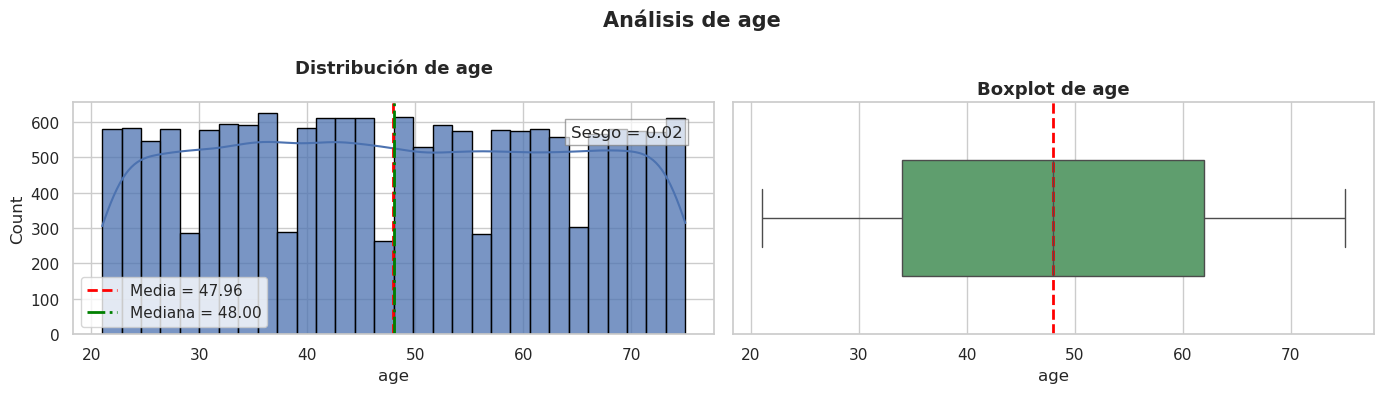

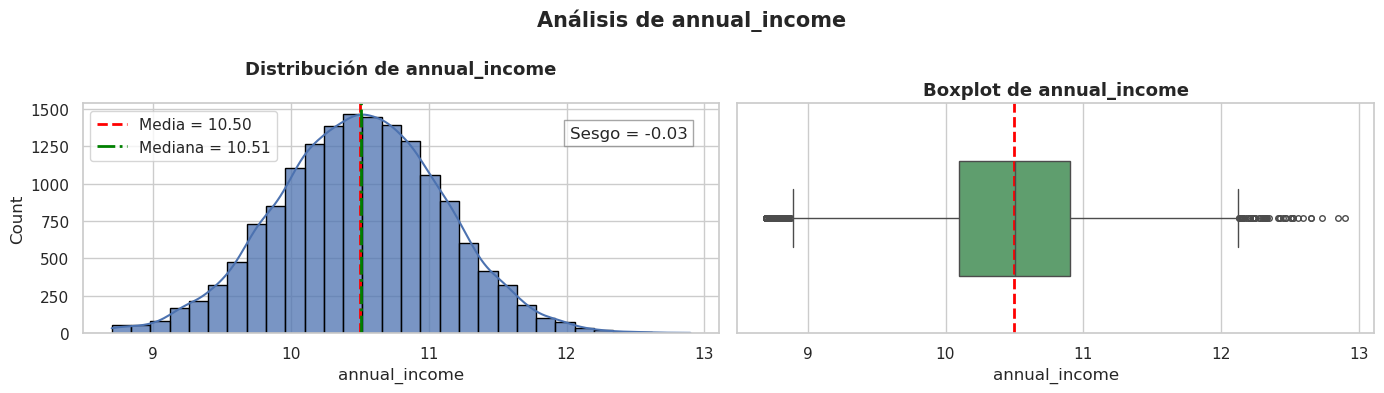

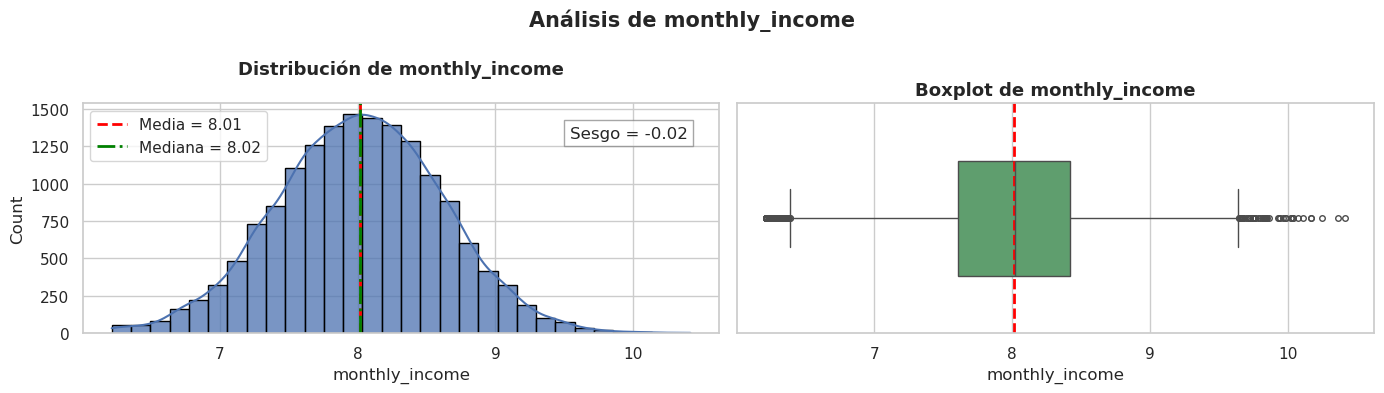

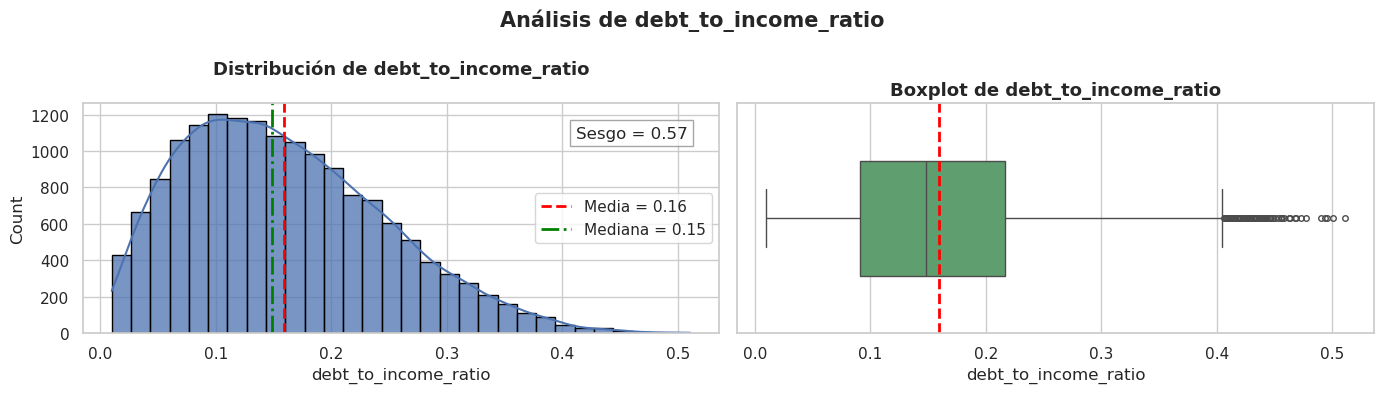

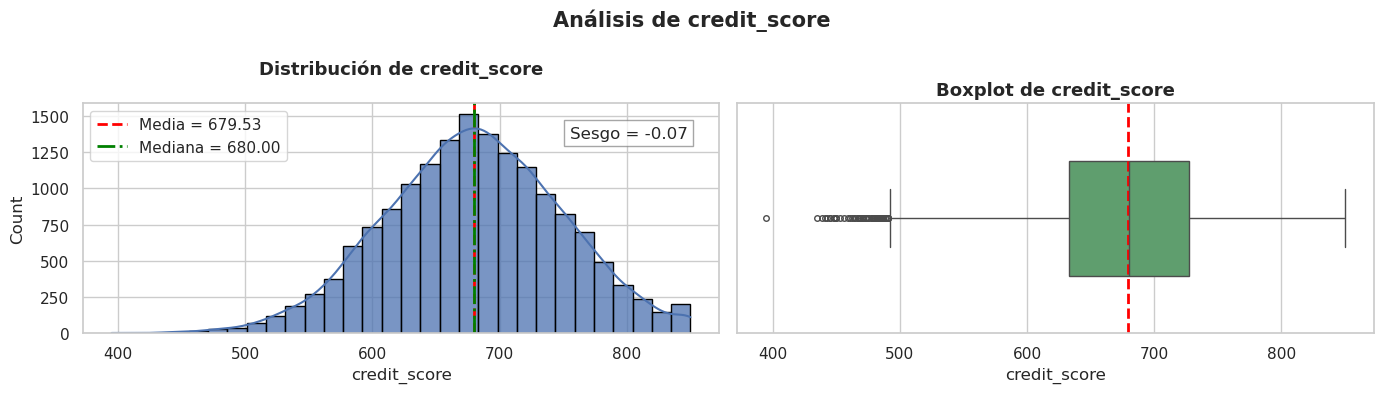

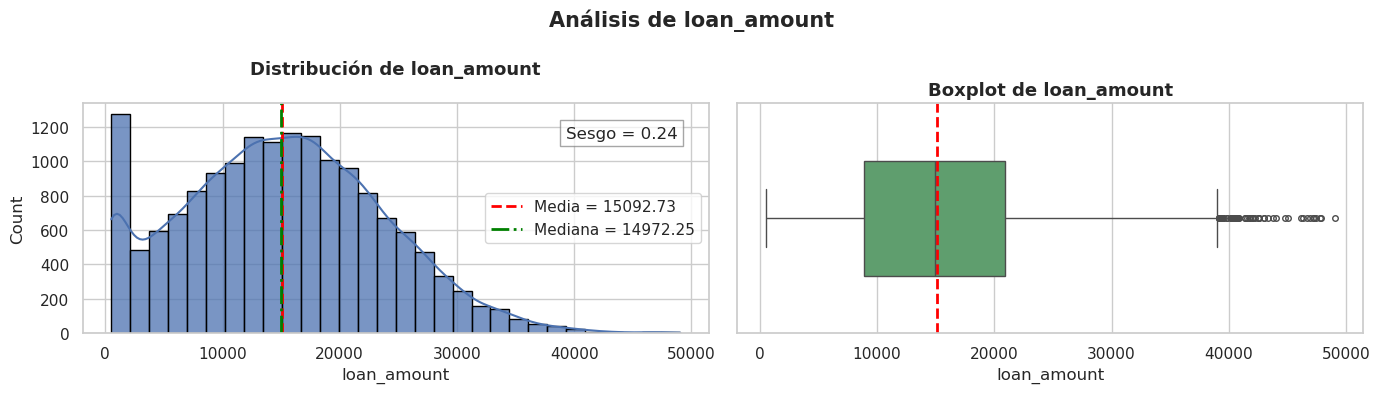

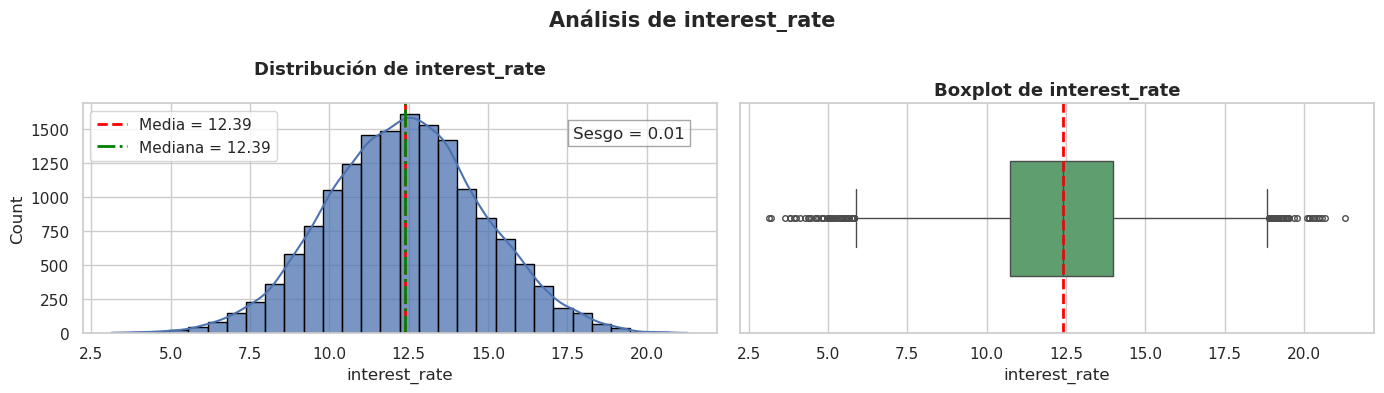

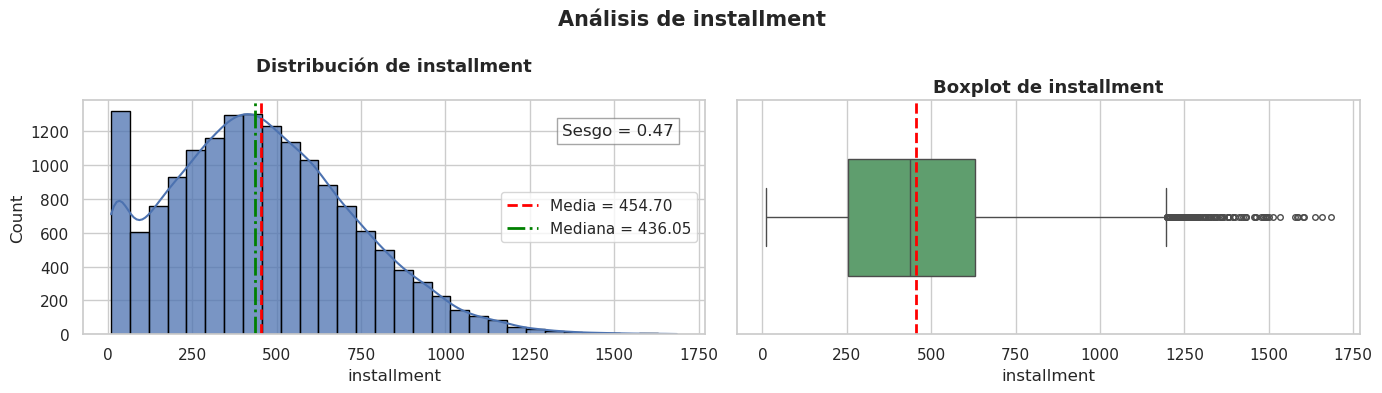

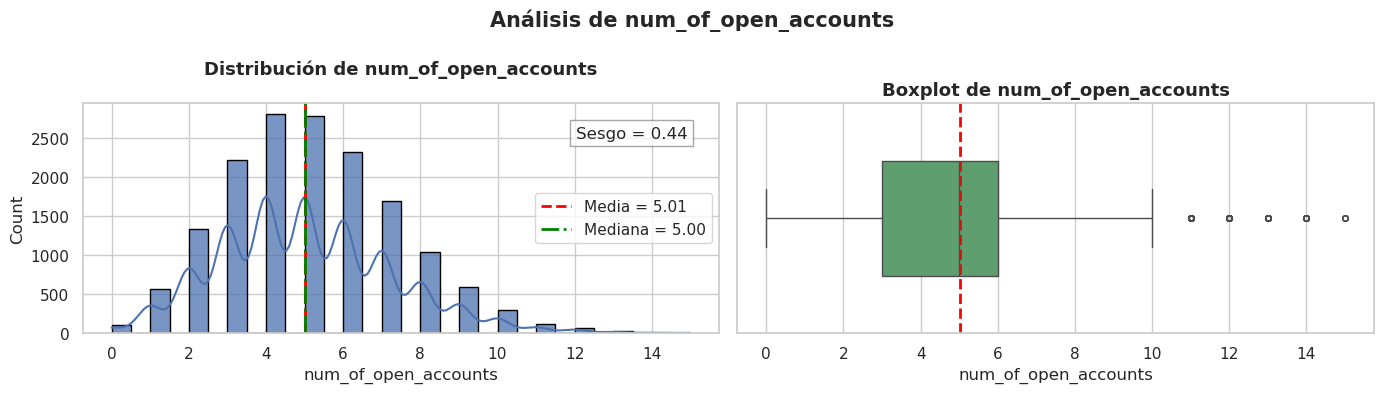

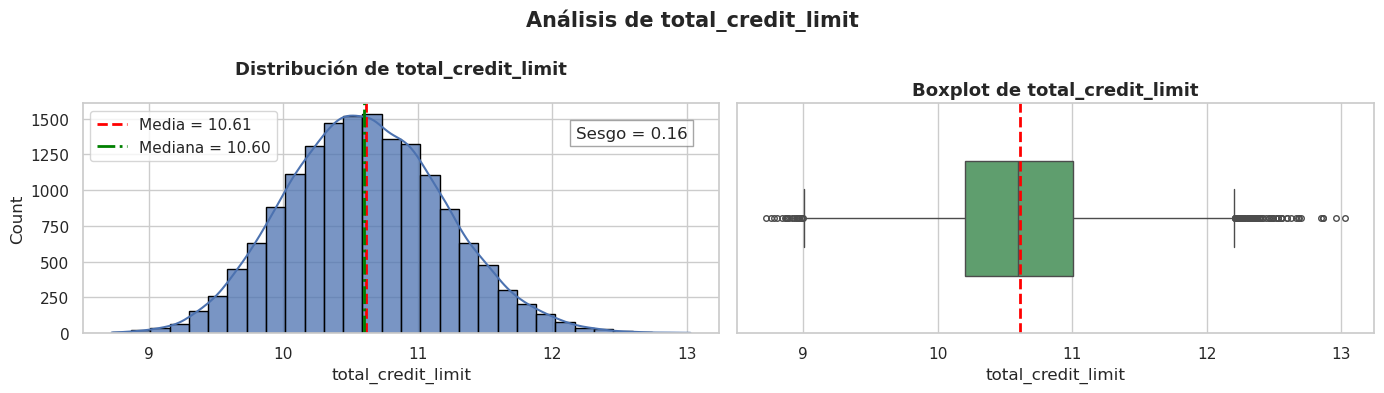

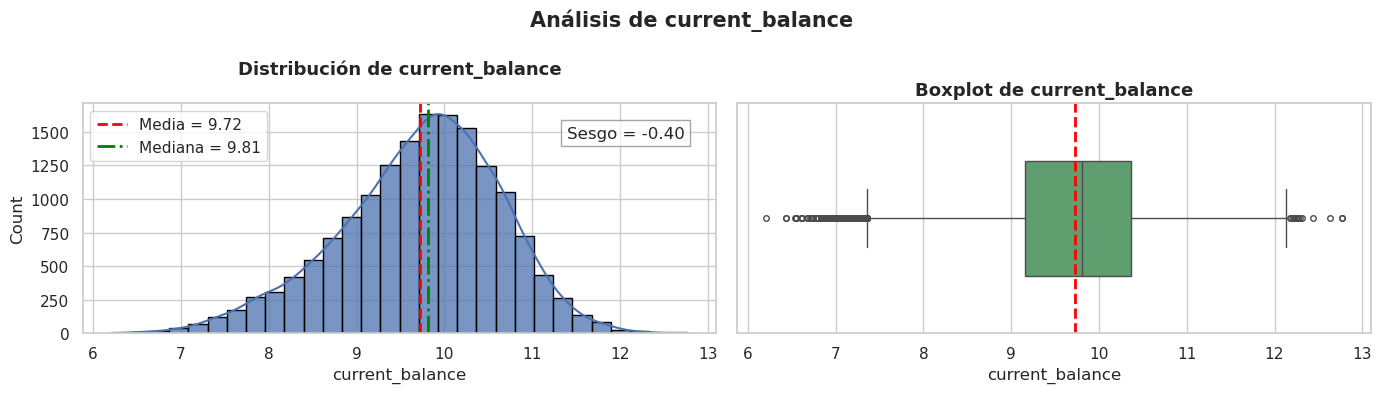

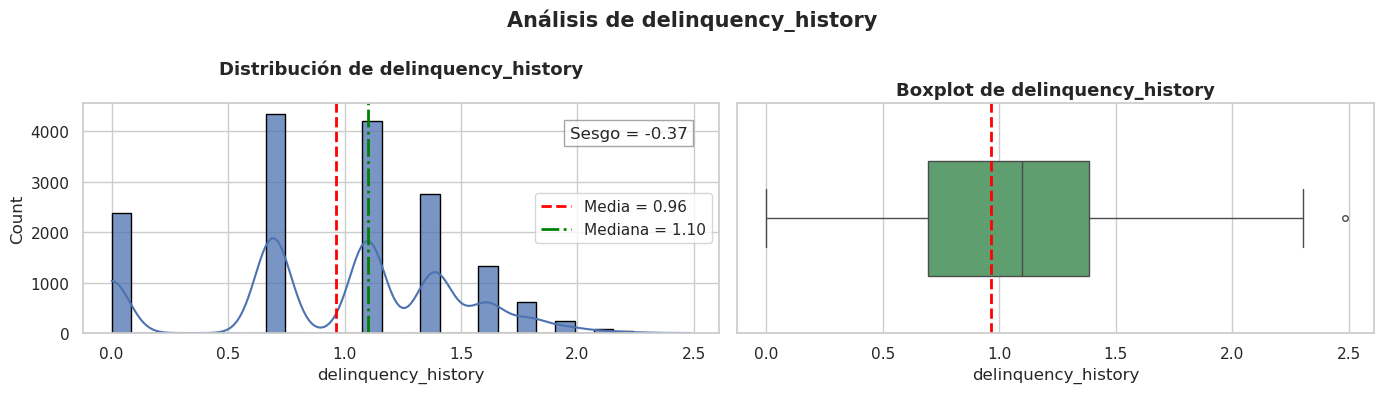

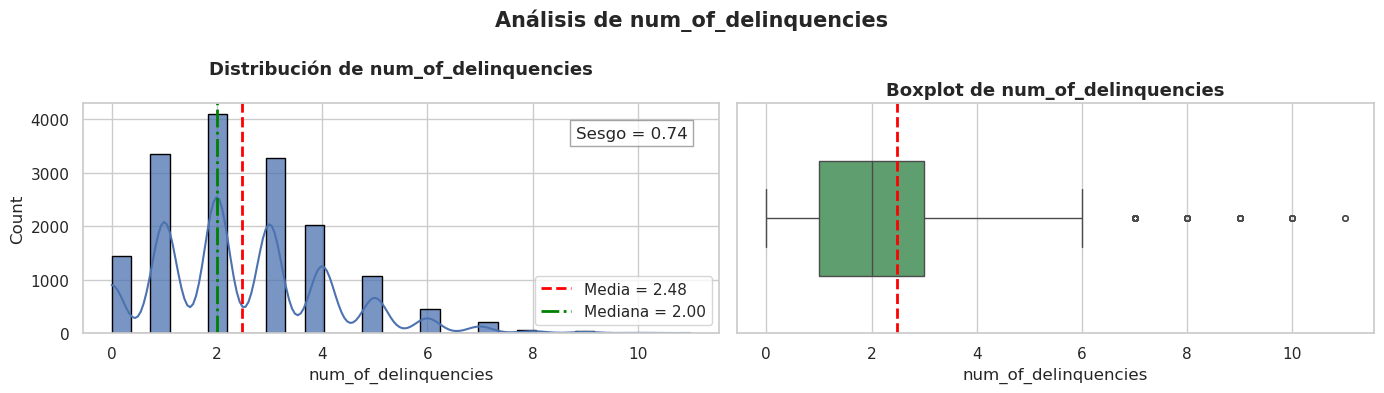

In [17]:
plot_distribucion_box(train, numeric_cols)

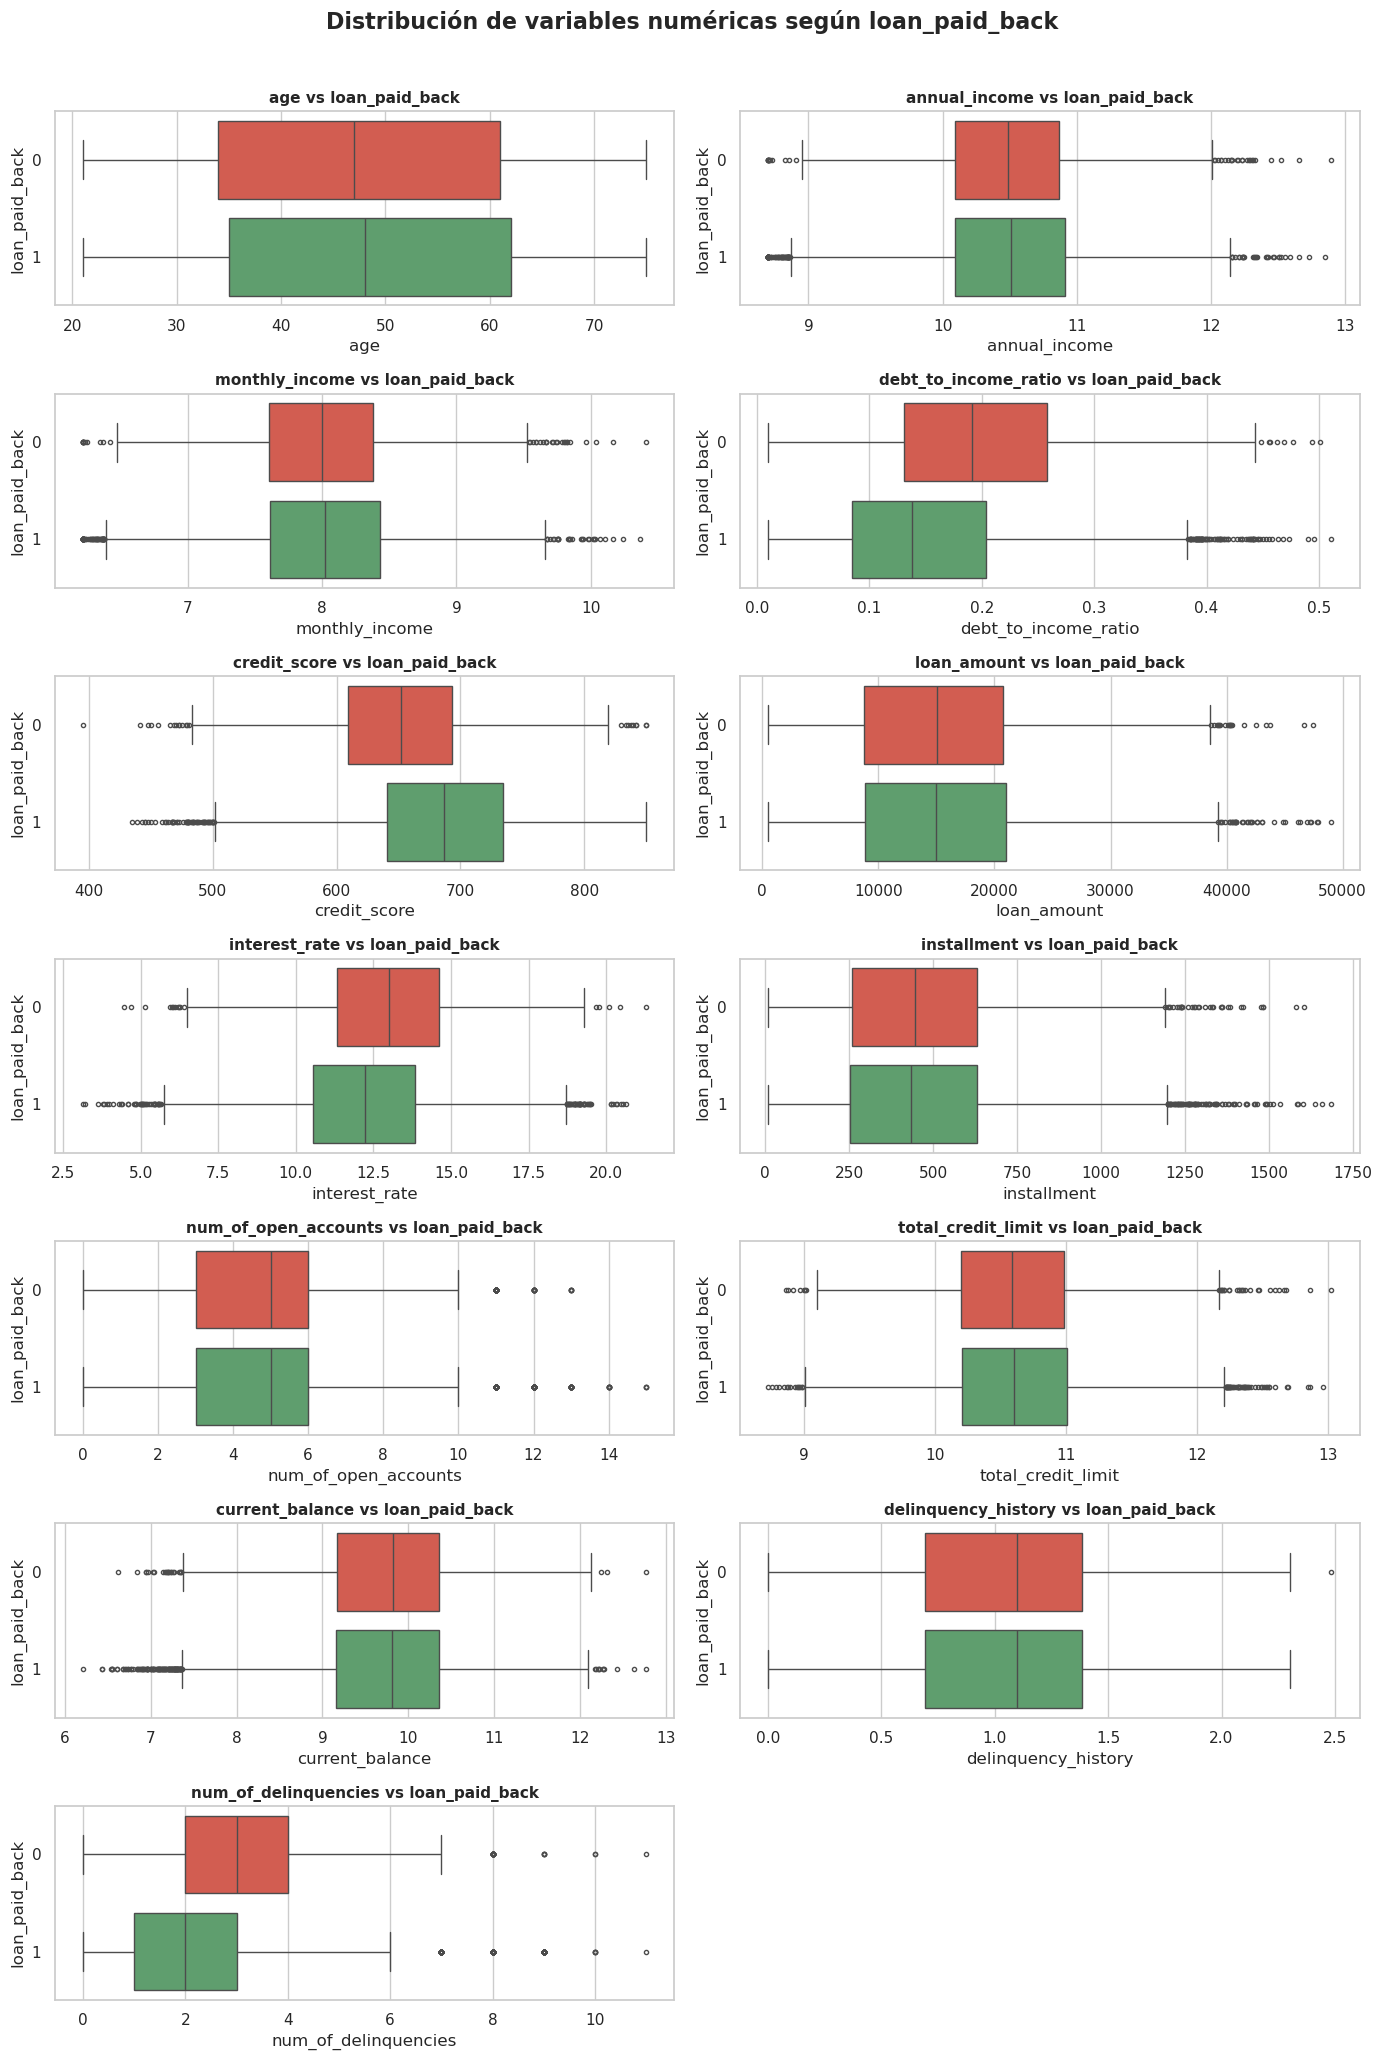

In [18]:
plot_boxplots_numericas_vs_target(train, numeric_cols, target=variable_objetivo)

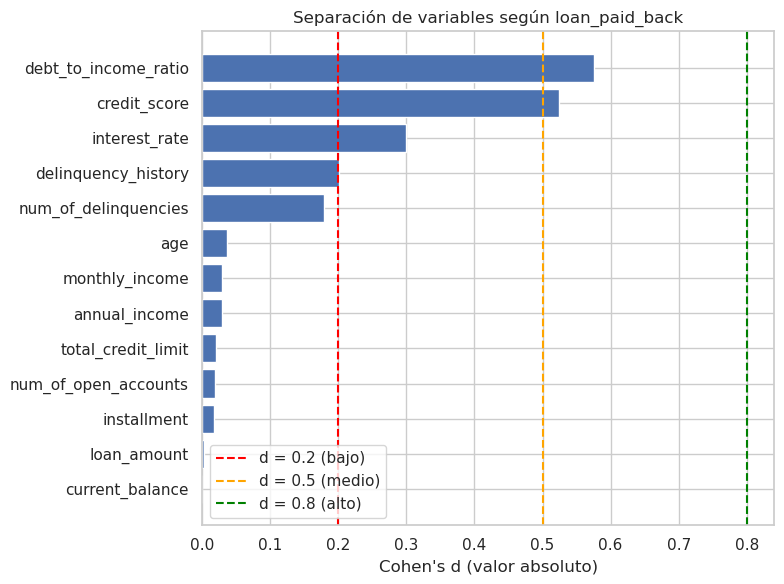

,Variable,Cohen_d
0,debt_to_income_ratio,0.575418
1,credit_score,0.523555
2,interest_rate,0.299234
3,delinquency_history,0.201359
4,num_of_delinquencies,0.179556
5,age,0.036785
6,monthly_income,0.028546
7,annual_income,0.028541
8,total_credit_limit,0.020160
9,num_of_open_accounts,0.018198


In [19]:
cohen_ranking(train, target= variable_objetivo, numeric_cols=numeric_cols)

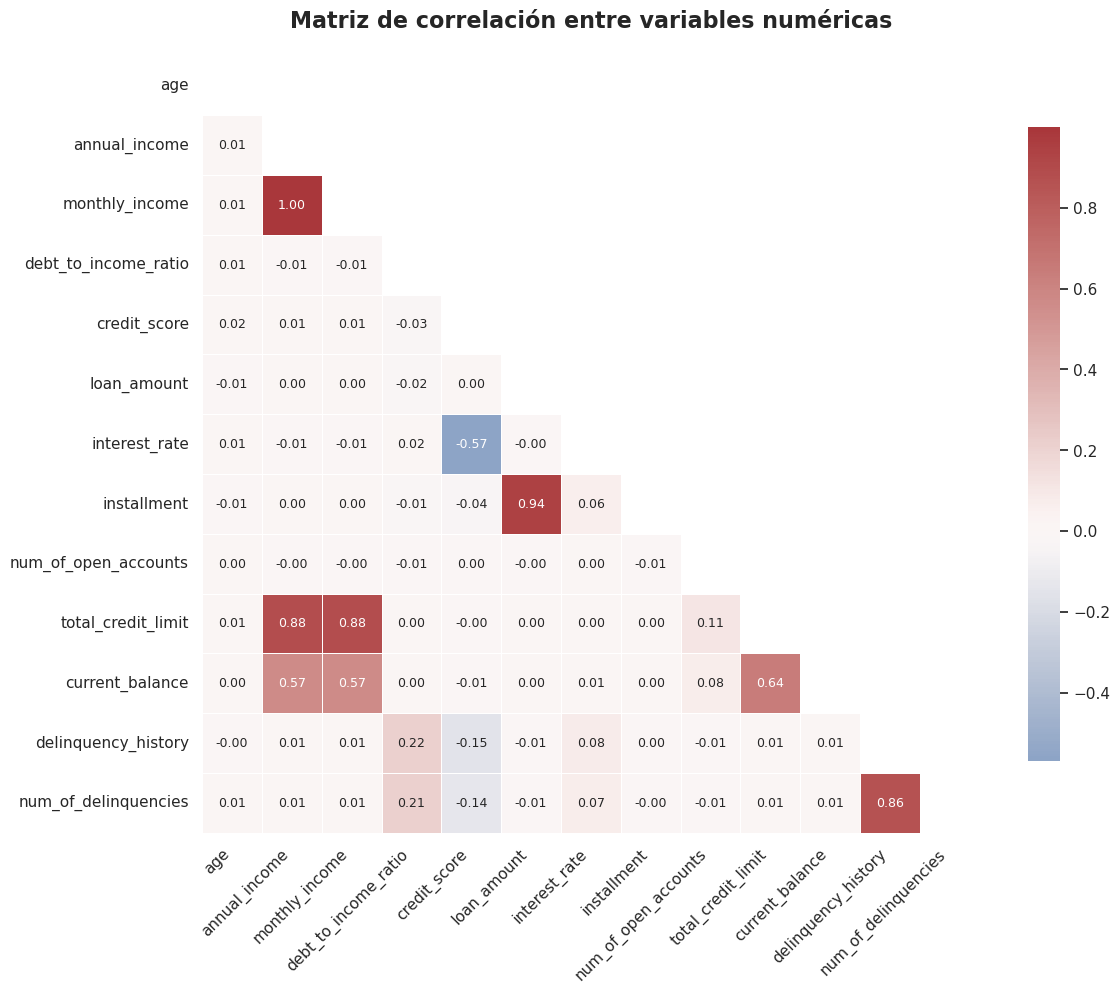

In [20]:
plot_corr_mat(train, numeric_cols)

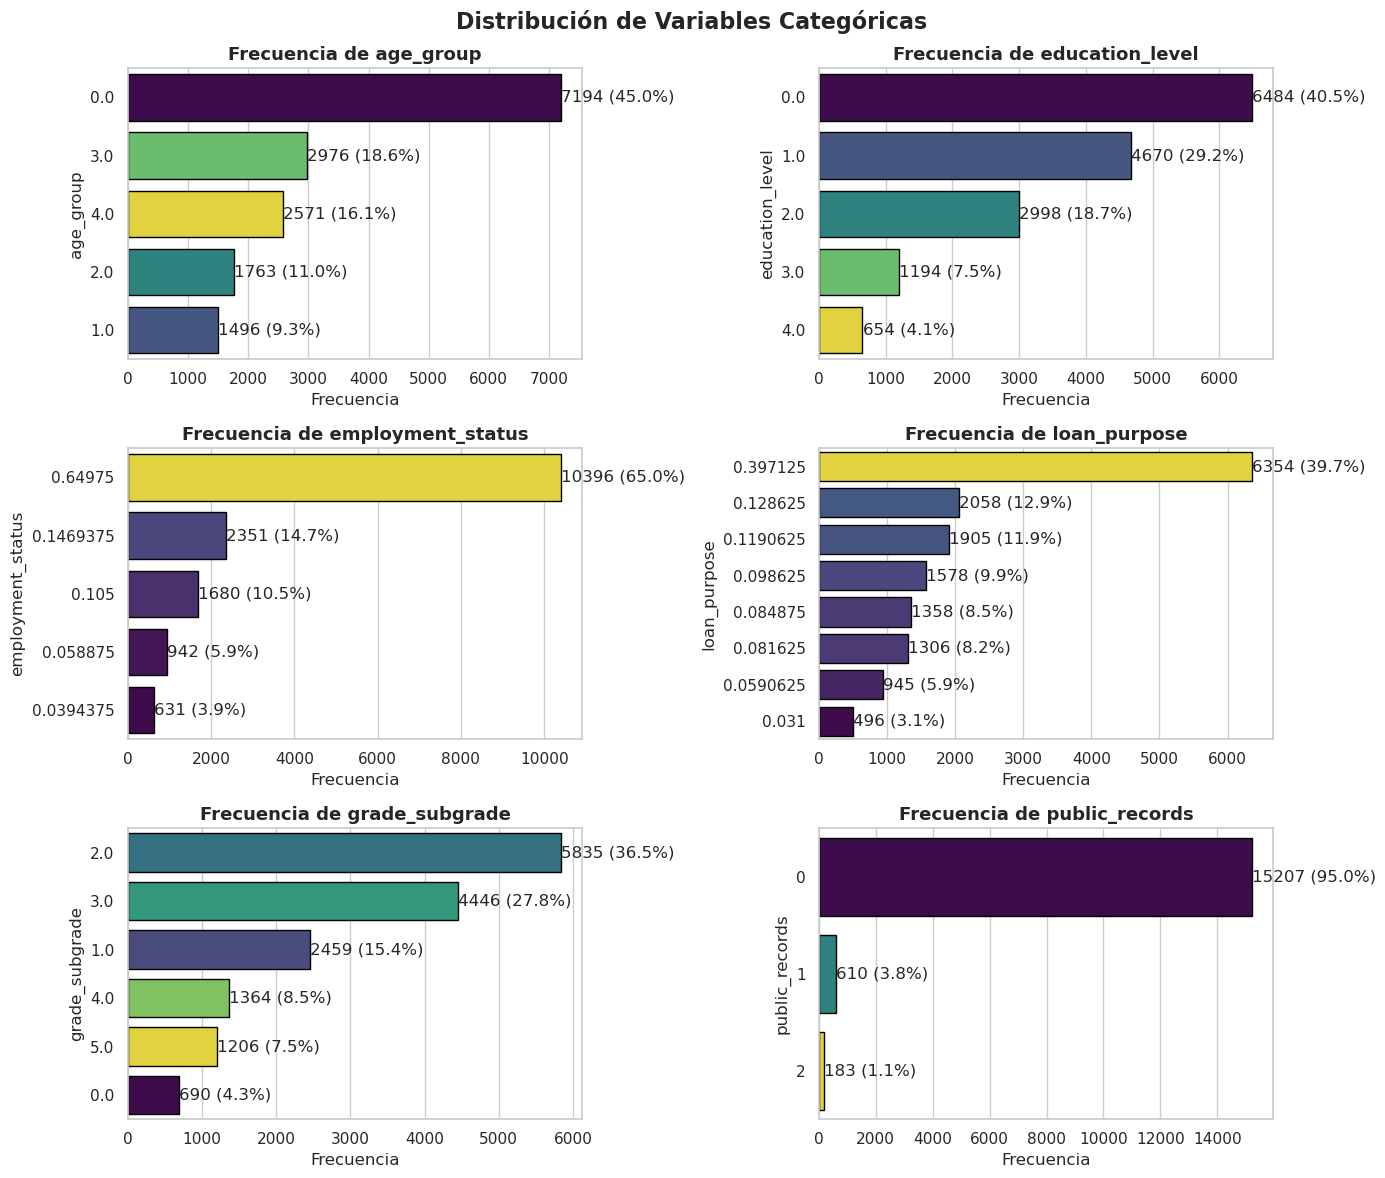

In [21]:
plot_frecuencias_categoricas(train, categoric_cols, show_percentage=True)

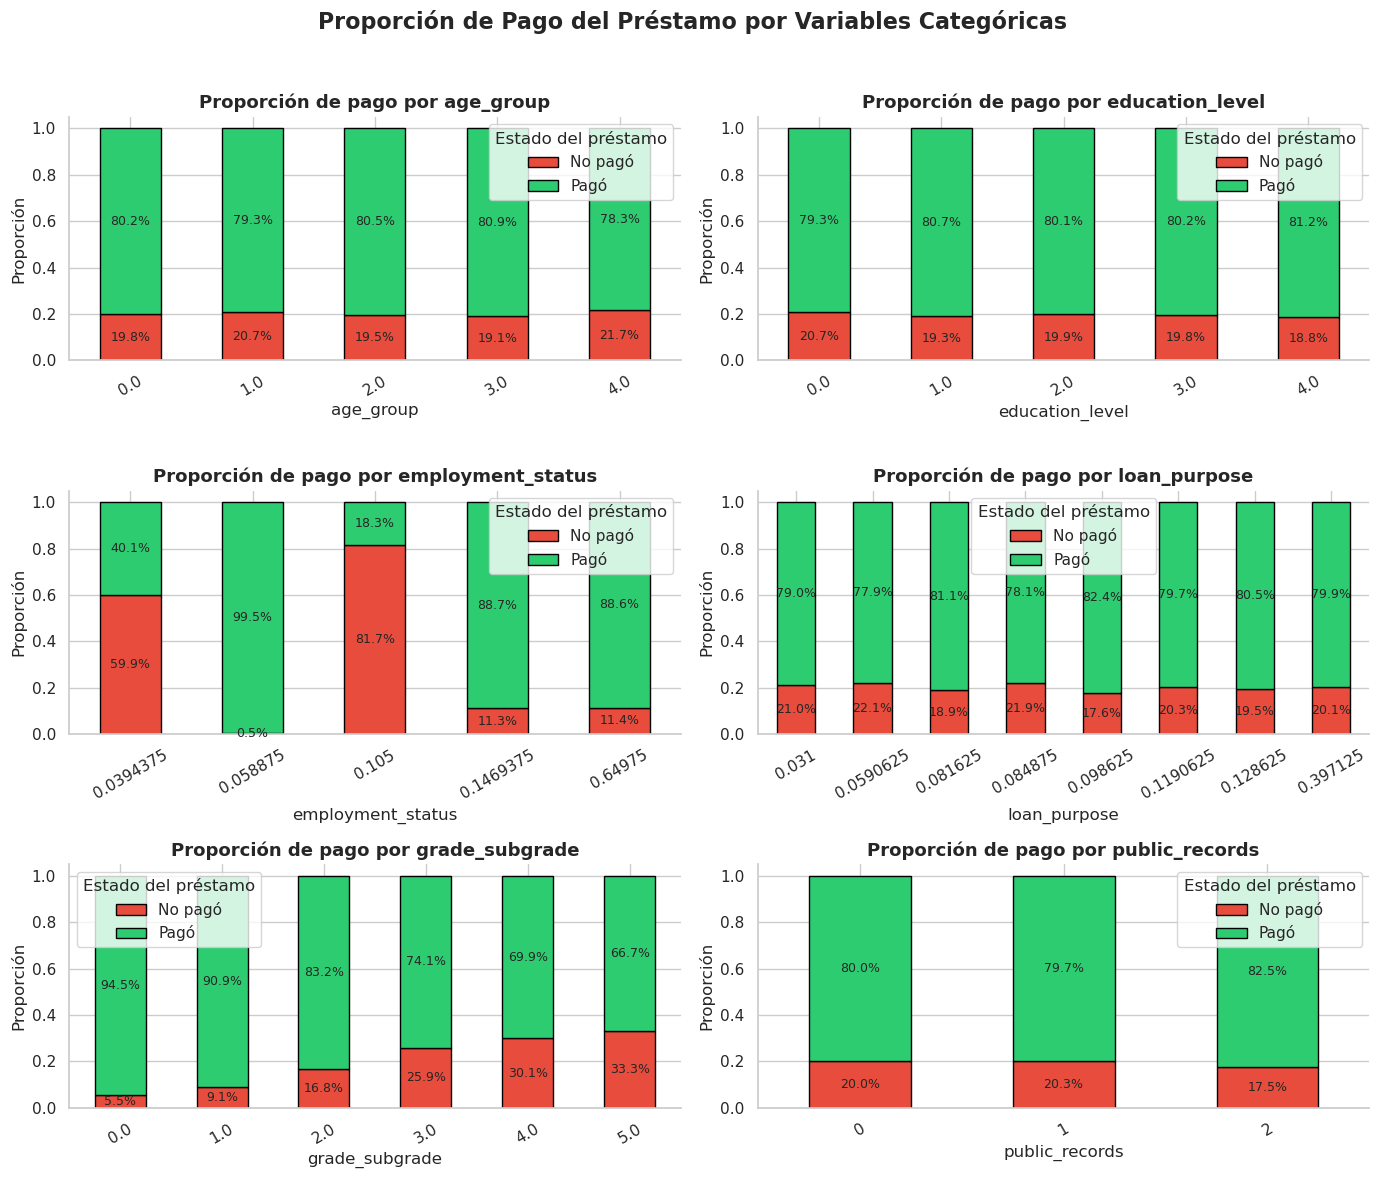

In [22]:
plot_crosstab_categoricas(
    train,
    categoric_cols,
    target=variable_objetivo)